"""
Food 101 - Exploratory Data Analysis (EDA) + Preprocesamiento
Notebook completo para análisis y limpieza de datos
"""

In [26]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter, defaultdict
from tqdm import tqdm

# Para cargar desde Kaggle Hub
import kagglehub

# Visión por computadora
import cv2
from PIL import Image

# Detección de rostros y manos
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

In [27]:
print("\n[PASO 1] Descargando dataset desde Kaggle Hub...")
print("-" * 80)

try:
    # Descargar usando kagglehub
    path = kagglehub.dataset_download("kmader/food41")
    print(f"✅ Dataset descargado en: {path}")
    DATASET_DIR = path
except Exception as e:
    print(f"⚠️  Error al descargar: {e}")
    print("💡 Asegúrate de tener credenciales de Kaggle configuradas")
    print("   Tutorial: https://github.com/Kaggle/kagglehub")


[PASO 1] Descargando dataset desde Kaggle Hub...
--------------------------------------------------------------------------------
✅ Dataset descargado en: C:\Users\Administrator\.cache\kagglehub\datasets\kmader\food41\versions\5


In [28]:
# ============================================================================
# PARTE 2: EXPLORACIÓN INICIAL DEL DATASET
# ============================================================================

print("\n[PASO 2] Exploración inicial del dataset...")
print("-" * 80)

# Encontrar carpeta de imágenes
images_path = os.path.join(DATASET_DIR, "images")
if not os.path.exists(images_path):
    images_path = DATASET_DIR

print(f"📂 Ruta imágenes: {images_path}")

# Listar clases (categorías de comida)
classes = sorted([d for d in os.listdir(images_path) 
                  if os.path.isdir(os.path.join(images_path, d))])
num_classes = len(classes)

print(f"📊 Número de clases: {num_classes}")
print(f"🍲 Primeras 10 clases: {classes[:10]}")

# Contar imágenes por clase
images_per_class = {}
total_images = 0

print("\n📈 Contando imágenes por clase...")
for class_name in tqdm(classes):
    class_path = os.path.join(images_path, class_name)
    num_images = len([f for f in os.listdir(class_path) 
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    images_per_class[class_name] = num_images
    total_images += num_images

print(f"✅ Total de imágenes: {total_images}")



[PASO 2] Exploración inicial del dataset...
--------------------------------------------------------------------------------
📂 Ruta imágenes: C:\Users\Administrator\.cache\kagglehub\datasets\kmader\food41\versions\5\images
📊 Número de clases: 101
🍲 Primeras 10 clases: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito']

📈 Contando imágenes por clase...


100%|██████████| 101/101 [00:00<00:00, 1371.23it/s]

✅ Total de imágenes: 101000


In [29]:
# ============================================================================
# PARTE 3: ANÁLISIS DESCRIPTIVO DEL DATASET
# ============================================================================

print("\n[PASO 3] Análisis descriptivo...")
print("-" * 80)

# Estadísticas básicas
df_classes = pd.DataFrame({
    'clase': list(images_per_class.keys()),
    'num_imagenes': list(images_per_class.values())
})

print("\n📋 Estadísticas por clase:")
print(df_classes.describe())

print(f"\n🔍 Imágenes por clase:")
print(f"   Min: {df_classes['num_imagenes'].min()}")
print(f"   Max: {df_classes['num_imagenes'].max()}")
print(f"   Media: {df_classes['num_imagenes'].mean():.1f}")
print(f"   Std: {df_classes['num_imagenes'].std():.1f}")

# Top 10 clases con más imágenes
top_10 = df_classes.nlargest(10, 'num_imagenes')
print(f"\n🏆 Top 10 clases con más imágenes:")
for idx, row in top_10.iterrows():
    print(f"   {row['clase']}: {row['num_imagenes']} imágenes")



[PASO 3] Análisis descriptivo...
--------------------------------------------------------------------------------

📋 Estadísticas por clase:
       num_imagenes
count         101.0
mean         1000.0
std             0.0
min          1000.0
25%          1000.0
50%          1000.0
75%          1000.0
max          1000.0

🔍 Imágenes por clase:
   Min: 1000
   Max: 1000
   Media: 1000.0
   Std: 0.0

🏆 Top 10 clases con más imágenes:
   apple_pie: 1000 imágenes
   baby_back_ribs: 1000 imágenes
   baklava: 1000 imágenes
   beef_carpaccio: 1000 imágenes
   beef_tartare: 1000 imágenes
   beet_salad: 1000 imágenes
   beignets: 1000 imágenes
   bibimbap: 1000 imágenes
   bread_pudding: 1000 imágenes
   breakfast_burrito: 1000 imágenes


In [30]:
# ============================================================================
# PARTE 4: EXPLORACIÓN DE CARACTERÍSTICAS DE IMÁGENES
# ============================================================================

print("\n[PASO 4] Explorando características de imágenes...")
print("-" * 80)

# Muestrear imágenes para análisis de características
image_features = []
sample_size = 500  # Muestrear 500 imágenes para no tardar

print(f"🔍 Analizando {sample_size} imágenes para características...")

np.random.seed(42)
classes_sample = np.random.choice(classes, size=min(20, len(classes)), replace=False)

for class_name in tqdm(classes_sample):
    class_path = os.path.join(images_path, class_name)
    images = [f for f in os.listdir(class_path) 
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    # Muestrear hasta 25 imágenes por clase
    for img_name in images[:25]:
        img_path = os.path.join(class_path, img_name)
        try:
            img = Image.open(img_path)
            width, height = img.size
            
            image_features.append({
                'clase': class_name,
                'width': width,
                'height': height,
                'aspect_ratio': width / height if height > 0 else 0,
                'mode': img.mode,
                'file_size_kb': os.path.getsize(img_path) / 1024
            })
        except Exception as e:
            print(f"   ⚠️  Error cargando {img_name}: {e}")

df_img_features = pd.DataFrame(image_features)

print(f"\n✅ Imágenes analizadas: {len(df_img_features)}")
print(f"\n📐 Dimensiones de imágenes:")
print(f"   Width - Min: {df_img_features['width'].min()}, "
      f"Max: {df_img_features['width'].max()}, "
      f"Media: {df_img_features['width'].mean():.0f}")
print(f"   Height - Min: {df_img_features['height'].min()}, "
      f"Max: {df_img_features['height'].max()}, "
      f"Media: {df_img_features['height'].mean():.0f}")

print(f"\n🎨 Modos de color:")
print(df_img_features['mode'].value_counts())

print(f"\n💾 Tamaño de archivos:")
print(f"   Min: {df_img_features['file_size_kb'].min():.1f} KB")
print(f"   Max: {df_img_features['file_size_kb'].max():.1f} KB")
print(f"   Media: {df_img_features['file_size_kb'].mean():.1f} KB")



[PASO 4] Explorando características de imágenes...
--------------------------------------------------------------------------------
🔍 Analizando 500 imágenes para características...


100%|██████████| 20/20 [00:00<00:00, 181.49it/s]


✅ Imágenes analizadas: 500

📐 Dimensiones de imágenes:
   Width - Min: 287, Max: 512, Media: 494
   Height - Min: 288, Max: 512, Media: 467

🎨 Modos de color:
mode
RGB    500
Name: count, dtype: int64

💾 Tamaño de archivos:
   Min: 18.6 KB
   Max: 121.2 KB
   Media: 50.2 KB


In [31]:
# ============================================================================
# PARTE 5 ULTRA-MEJORADA: DETECCIÓN REALISTA DE IMÁGENES RUIDOSAS
# Ajustado para NO confundir comida con personas
# ============================================================================

print("\n[PASO 5] Detección de imágenes ruidosas (ULTRA-REALISTA)...")
print("-" * 80)

from PIL import Image, ImageStat, ImageFilter, ImageDraw
from scipy import ndimage
import numpy as np
from collections import Counter

class ImageQualityChecker:
    """
    Detector ULTRA-CONSERVADOR que solo marca imágenes obviamente problemáticas
    """
    
    def __init__(self):
        pass
    
    def detect_human_skin(self, img_path):
        """
        Detección MUY estricta de piel humana
        Usa múltiples criterios para NO confundir con comida
        """
        try:
            img = Image.open(img_path).convert('RGB')
            img_array = np.array(img)
            
            r = img_array[:, :, 0].astype(float)
            g = img_array[:, :, 1].astype(float)
            b = img_array[:, :, 2].astype(float)
            
            # CRITERIOS MUY ESTRICTOS para piel humana
            # Basado en: "Efficient Elliptical Skin Detection"
            
            # Criterio 1: Rangos RGB muy específicos (no comida dorada)
            rgb_cond = (
                (r > 95) & (r < 255) &
                (g > 40) & (g < 220) &
                (b > 20) & (b < 200) &
                (r > g) & (g > b)
            )
            
            # Criterio 2: Diferencias entre canales (piel humana tiene patrones específicos)
            diff_rg = r - g
            diff_rb = r - b
            diff_cond = (diff_rg > 15) & (diff_rb > 15) & (diff_rg < 80)
            
            # Criterio 3: Ratios RGB (piel humana tiene ratios específicos)
            # Evita comida muy roja/naranja
            with np.errstate(divide='ignore', invalid='ignore'):
                ratio_rg = r / (g + 1)
                ratio_rb = r / (b + 1)
                
                ratio_cond = (ratio_rg > 1.0) & (ratio_rg < 2.5) & (ratio_rb > 1.0) & (ratio_rb < 3.0)
            
            # Criterio 4: Saturación (piel tiene saturación media, comida puede ser más saturada)
            hsv_img = img.convert('HSV')
            hsv_array = np.array(hsv_img)
            saturation = hsv_array[:, :, 1]
            sat_cond = (saturation > 20) & (saturation < 150)  # Piel no es muy saturada
            
            # TODOS los criterios deben cumplirse
            skin_mask = rgb_cond & diff_cond & ratio_cond & sat_cond
            
            # Calcular porcentaje
            total_pixels = img_array.shape[0] * img_array.shape[1]
            skin_pixels = np.count_nonzero(skin_mask)
            skin_percentage = (skin_pixels / total_pixels) * 100
            
            # THRESHOLD MUY ALTO: solo marcar si >40% es piel (personas en primer plano)
            has_suspicious_skin = skin_percentage > 40
            
            return has_suspicious_skin, skin_percentage
            
        except Exception as e:
            return False, 0.0
    
    def detect_face_structure(self, img_path):
        """
        Busca ESTRUCTURAS faciales reales (ojos, simetría)
        No solo color
        """
        try:
            img = Image.open(img_path).convert('L')
            img_small = img.resize((100, 100))
            img_array = np.array(img_small)
            
            # Aplicar detección de bordes fuerte
            from scipy.ndimage import sobel
            
            # Gradientes horizontal y vertical
            sx = sobel(img_array, axis=0, mode='constant')
            sy = sobel(img_array, axis=1, mode='constant')
            sobel_img = np.hypot(sx, sy)
            
            # Buscar regiones circulares/ovaladas (caras)
            # Dividir en grid 3x3
            h, w = sobel_img.shape
            grid_h, grid_w = h // 3, w // 3
            
            oval_scores = []
            for i in range(3):
                for j in range(3):
                    region = sobel_img[i*grid_h:(i+1)*grid_h, j*grid_w:(j+1)*grid_w]
                    
                    # Buscar bordes circulares
                    center_mass = np.mean(region)
                    edge_variance = np.std(region)
                    
                    # Score: bordes uniformes alrededor = posible cara
                    oval_score = edge_variance / (center_mass + 1)
                    oval_scores.append(oval_score)
            
            # Si alguna región tiene patrón facial muy fuerte
            max_oval_score = max(oval_scores)
            
            # Threshold MUY alto
            has_face_structure = max_oval_score > 2.0
            
            return has_face_structure, max_oval_score
            
        except Exception as e:
            return False, 0.0
    
    def detect_symmetry(self, img_path):
        """
        Caras humanas son simétricas verticalmente
        Comida NO suele ser simétrica
        """
        try:
            img = Image.open(img_path).convert('L')
            img_small = img.resize((100, 100))
            img_array = np.array(img_small)
            
            # Dividir imagen verticalmente
            mid = img_array.shape[1] // 2
            left_half = img_array[:, :mid]
            right_half = np.fliplr(img_array[:, mid:])
            
            # Ajustar tamaños si son impares
            min_width = min(left_half.shape[1], right_half.shape[1])
            left_half = left_half[:, :min_width]
            right_half = right_half[:, :min_width]
            
            # Calcular similitud
            diff = np.abs(left_half.astype(float) - right_half.astype(float))
            similarity = 1 - (np.mean(diff) / 255.0)
            
            # Caras tienen >75% de simetría
            is_symmetric = similarity > 0.75
            
            return is_symmetric, similarity
            
        except Exception as e:
            return False, 0.0
    
    def detect_hands_realistic(self, img_path):
        """
        Detecta manos REALES sosteniendo objetos
        Busca:
        1. Piel en bordes (manos suelen estar en bordes sosteniendo)
        2. Dedos (líneas delgadas de piel)
        """
        try:
            img = Image.open(img_path).convert('RGB')
            img_array = np.array(img)
            
            h, w = img_array.shape[:2]
            
            # Solo analizar bordes de la imagen (20% superior/inferior/laterales)
            border_width = int(w * 0.2)
            border_height = int(h * 0.2)
            
            # Extraer bordes
            top_border = img_array[:border_height, :]
            bottom_border = img_array[-border_height:, :]
            left_border = img_array[:, :border_width]
            right_border = img_array[:, -border_width:]
            
            borders = [top_border, bottom_border, left_border, right_border]
            
            skin_in_borders = []
            for border in borders:
                r = border[:, :, 0].astype(float)
                g = border[:, :, 1].astype(float)
                b = border[:, :, 2].astype(float)
                
                # Detección estricta de piel
                skin_cond = (
                    (r > 95) & (g > 40) & (b > 20) &
                    (r > g) & (g > b) &
                    ((r - g) > 15)
                )
                
                skin_pct = np.count_nonzero(skin_cond) / border.size * 100
                skin_in_borders.append(skin_pct)
            
            # Si algún borde tiene >30% de piel = probablemente mano sosteniendo
            max_skin_border = max(skin_in_borders)
            has_hands = max_skin_border > 30
            
            return has_hands, max_skin_border
            
        except Exception as e:
            return False, 0.0
    
    def check_image_sharpness(self, img_path):
        """Nitidez usando varianza de gradientes"""
        try:
            img = Image.open(img_path).convert('L')
            img_array = np.array(img)
            
            # Calcular gradientes
            from scipy.ndimage import sobel
            sx = sobel(img_array, axis=0)
            sy = sobel(img_array, axis=1)
            gradient_magnitude = np.hypot(sx, sy)
            
            # Nitidez = varianza de gradientes
            sharpness = np.var(gradient_magnitude)
            
            # Umbral bajo: solo marcar muy borrosas
            is_sharp = sharpness > 50
            
            return is_sharp, sharpness
            
        except Exception as e:
            return True, 0.0  # Por defecto asumir nítida
    
    def check_brightness_contrast(self, img_path):
        """Brillo y contraste"""
        try:
            img = Image.open(img_path).convert('L')
            stat = ImageStat.Stat(img)
            
            brightness = stat.mean[0]
            contrast = stat.stddev[0]
            
            # Rangos muy amplios (solo marcar imágenes MUY malas)
            is_bright = 30 < brightness < 230
            is_contrast = contrast > 20
            
            return (is_bright and is_contrast), brightness, contrast
            
        except Exception as e:
            return True, 0.0, 0.0
    
    def check_food_characteristics(self, img_path):
        """
        Verifica características típicas de comida:
        - Colores cálidos/variados
        - Texturas orgánicas
        - No simetría perfecta
        """
        try:
            img = Image.open(img_path).convert('RGB')
            img_small = img.resize((50, 50))
            
            # Obtener colores dominantes
            pixels = list(img_small.getdata())
            
            # Analizar distribución de colores
            colors_red = [p[0] for p in pixels]
            colors_green = [p[1] for p in pixels]
            colors_blue = [p[2] for p in pixels]
            
            # Comida suele tener:
            # 1. Variedad de colores
            std_r = np.std(colors_red)
            std_g = np.std(colors_green)
            std_b = np.std(colors_blue)
            color_variance = (std_r + std_g + std_b) / 3
            
            # 2. Tonos cálidos dominantes (rojo/amarillo)
            mean_r = np.mean(colors_red)
            mean_g = np.mean(colors_green)
            mean_b = np.mean(colors_blue)
            
            is_warm = mean_r > mean_b  # Más rojo que azul
            has_variance = color_variance > 30  # Variedad de tonos
            
            is_food_like = is_warm and has_variance
            
            return is_food_like, color_variance
            
        except Exception as e:
            return True, 0.0
    
    def analyze_image(self, img_path):
        """
        Análisis ULTRA-CONSERVADOR
        Solo marca como problemática si hay EVIDENCIA CLARA de personas
        """
        try:
            # 1. Detectar piel humana (MUY estricto)
            has_skin, skin_pct = self.detect_human_skin(img_path)
            
            # 2. Detectar estructura facial
            has_face_struct, face_score = self.detect_face_structure(img_path)
            
            # 3. Detectar simetría (típico de caras)
            is_symmetric, symmetry_score = self.detect_symmetry(img_path)
            
            # 4. Detectar manos en bordes
            has_hands, hands_score = self.detect_hands_realistic(img_path)
            
            # 5. Verificar características de comida
            is_food, food_score = self.check_food_characteristics(img_path)
            
            # 6. Calidad básica
            is_sharp, sharpness = self.check_image_sharpness(img_path)
            is_quality_bc, brightness, contrast = self.check_brightness_contrast(img_path)
            
            # CRITERIO FINAL (MUY ESTRICTO):
            # Solo marcar como problemática si:
            # - Tiene rostro (estructura + simetría + piel)
            # - O tiene manos obvias en bordes
            # - O NO parece comida Y tiene mucha piel
            
            has_face = (has_face_struct and is_symmetric and has_skin)
            has_obvious_person = has_face or (has_hands and skin_pct > 35)
            not_food_with_skin = (not is_food and has_skin)
            
            is_problematic = (
                has_obvious_person or
                not_food_with_skin or
                (not is_sharp and skin_pct > 50)  # Borrosa con mucha piel
            )
            
            return {
                'tiene_rostro': has_face,
                'face_structure_score': face_score,
                'symmetry_score': symmetry_score,
                'tiene_manos_obvias': has_hands,
                'hands_score': hands_score,
                'porcentaje_piel': skin_pct,
                'es_comida': is_food,
                'food_score': food_score,
                'es_nitida': is_sharp,
                'sharpness_score': sharpness,
                'buen_brillo_contraste': is_quality_bc,
                'brightness': brightness,
                'contrast': contrast,
                'es_problematica': is_problematic
            }
            
        except Exception as e:
            print(f"   Error: {e}")
            return None


# ============================================================================
# EJECUTAR ANÁLISIS
# ============================================================================

print("🔎 Analizando calidad con criterios ULTRA-REALISTAS...")

# Verificar si scipy está disponible
try:
    from scipy import ndimage
    from scipy.ndimage import sobel
    has_scipy = True
except ImportError:
    print("⚠️  scipy no disponible, usando métodos alternativos...")
    has_scipy = False

checker = ImageQualityChecker()
quality_results = []

sample_images = 300
img_count = 0

print(f"\nAnalizando {sample_images} imágenes...")

for class_name in tqdm(classes[:15], desc="Clases"):
    class_path = os.path.join(images_path, class_name)
    images = [f for f in os.listdir(class_path) 
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    for img_name in images[:20]:
        if img_count >= sample_images:
            break
        
        img_path = os.path.join(class_path, img_name)
        result = checker.analyze_image(img_path)
        
        if result:
            result['clase'] = class_name
            result['imagen'] = img_name
            quality_results.append(result)
            img_count += 1
    
    if img_count >= sample_images:
        break

df_quality = pd.DataFrame(quality_results)

# ============================================================================
# ESTADÍSTICAS REALISTAS
# ============================================================================

print(f"\n✅ Imágenes analizadas: {len(df_quality)}")

if len(df_quality) > 0:
    print(f"\n⚠️  Problemas detectados (CRITERIOS ESTRICTOS):")
    
    num_faces = df_quality['tiene_rostro'].sum()
    pct_faces = 100 * num_faces / len(df_quality)
    print(f"   👤 Rostros humanos detectados: {num_faces} ({pct_faces:.1f}%)")
    
    num_hands = df_quality['tiene_manos_obvias'].sum()
    pct_hands = 100 * num_hands / len(df_quality)
    print(f"   ✋ Manos sosteniendo comida: {num_hands} ({pct_hands:.1f}%)")
    
    num_not_food = (~df_quality['es_comida']).sum()
    pct_not_food = 100 * num_not_food / len(df_quality)
    print(f"   🚫 NO parece comida: {num_not_food} ({pct_not_food:.1f}%)")
    
    num_blurry = (~df_quality['es_nitida']).sum()
    pct_blurry = 100 * num_blurry / len(df_quality)
    print(f"   📷 Imágenes muy borrosas: {num_blurry} ({pct_blurry:.1f}%)")
    
    num_bad_light = (~df_quality['buen_brillo_contraste']).sum()
    pct_bad_light = 100 * num_bad_light / len(df_quality)
    print(f"   💡 Iluminación extrema: {num_bad_light} ({pct_bad_light:.1f}%)")
    
    problematic_images = df_quality['es_problematica'].sum()
    pct_problematic = 100 * problematic_images / len(df_quality)
    print(f"\n   ❌ TOTAL PROBLEMÁTICAS: {problematic_images} ({pct_problematic:.1f}%)")
    
    print(f"\n📊 Estadísticas promedio:")
    print(f"   Porcentaje piel detectado: {df_quality['porcentaje_piel'].mean():.1f}%")
    print(f"   Score de estructura facial: {df_quality['face_structure_score'].mean():.3f}")
    print(f"   Score de simetría: {df_quality['symmetry_score'].mean():.3f}")
    print(f"   Nitidez: {df_quality['sharpness_score'].mean():.1f}")
    
    # Mostrar ejemplos problemáticos
    problematic_df = df_quality[df_quality['es_problematica']]
    if len(problematic_df) > 0:
        print(f"\n🔍 Ejemplos de imágenes REALMENTE problemáticas:")
        for idx, row in problematic_df.head(5).iterrows():
            reasons = []
            if row['tiene_rostro']:
                reasons.append(f"ROSTRO HUMANO (simetría: {row['symmetry_score']:.2f})")
            if row['tiene_manos_obvias']:
                reasons.append(f"MANOS en bordes ({row['hands_score']:.1f}%)")
            if not row['es_comida']:
                reasons.append("NO es comida")
            if not row['es_nitida'] and row['porcentaje_piel'] > 50:
                reasons.append("Borrosa con mucha piel")
            
            print(f"   • {row['clase']}/{row['imagen']}")
            print(f"     Razones: {', '.join(reasons)}")
            print(f"     Piel: {row['porcentaje_piel']:.1f}%")
    else:
        print(f"\n✅ ¡Excelente! No se detectaron imágenes problemáticas")
        print(f"   El dataset parece limpio y enfocado en comida")

else:
    print("⚠️ No se pudo analizar ninguna imagen")


[PASO 5] Detección de imágenes ruidosas (ULTRA-REALISTA)...
--------------------------------------------------------------------------------
🔎 Analizando calidad con criterios ULTRA-REALISTAS...

Analizando 300 imágenes...


Clases:  93%|█████████▎| 14/15 [00:19<00:01,  1.41s/it]


✅ Imágenes analizadas: 300

⚠️  Problemas detectados (CRITERIOS ESTRICTOS):
   👤 Rostros humanos detectados: 24 (8.0%)
   ✋ Manos sosteniendo comida: 13 (4.3%)
   🚫 NO parece comida: 14 (4.7%)
   📷 Imágenes muy borrosas: 0 (0.0%)
   💡 Iluminación extrema: 1 (0.3%)

   ❌ TOTAL PROBLEMÁTICAS: 26 (8.7%)

📊 Estadísticas promedio:
   Porcentaje piel detectado: 16.7%
   Score de estructura facial: inf
   Score de simetría: 0.807
   Nitidez: inf

🔍 Ejemplos de imágenes REALMENTE problemáticas:
   • apple_pie/101251.jpg
     Razones: ROSTRO HUMANO (simetría: 0.90), NO es comida
     Piel: 54.5%
   • apple_pie/1074942.jpg
     Razones: ROSTRO HUMANO (simetría: 0.92), NO es comida
     Piel: 49.0%
   • baby_back_ribs/1081312.jpg
     Razones: ROSTRO HUMANO (simetría: 0.85)
     Piel: 41.8%
   • baklava/1024334.jpg
     Razones: ROSTRO HUMANO (simetría: 0.86)
     Piel: 43.4%
   • baklava/1049559.jpg
     Razones: ROSTRO HUMANO (simetría: 0.81)
     Piel: 42.4%



[PASO 6] Generando visualizaciones...
--------------------------------------------------------------------------------


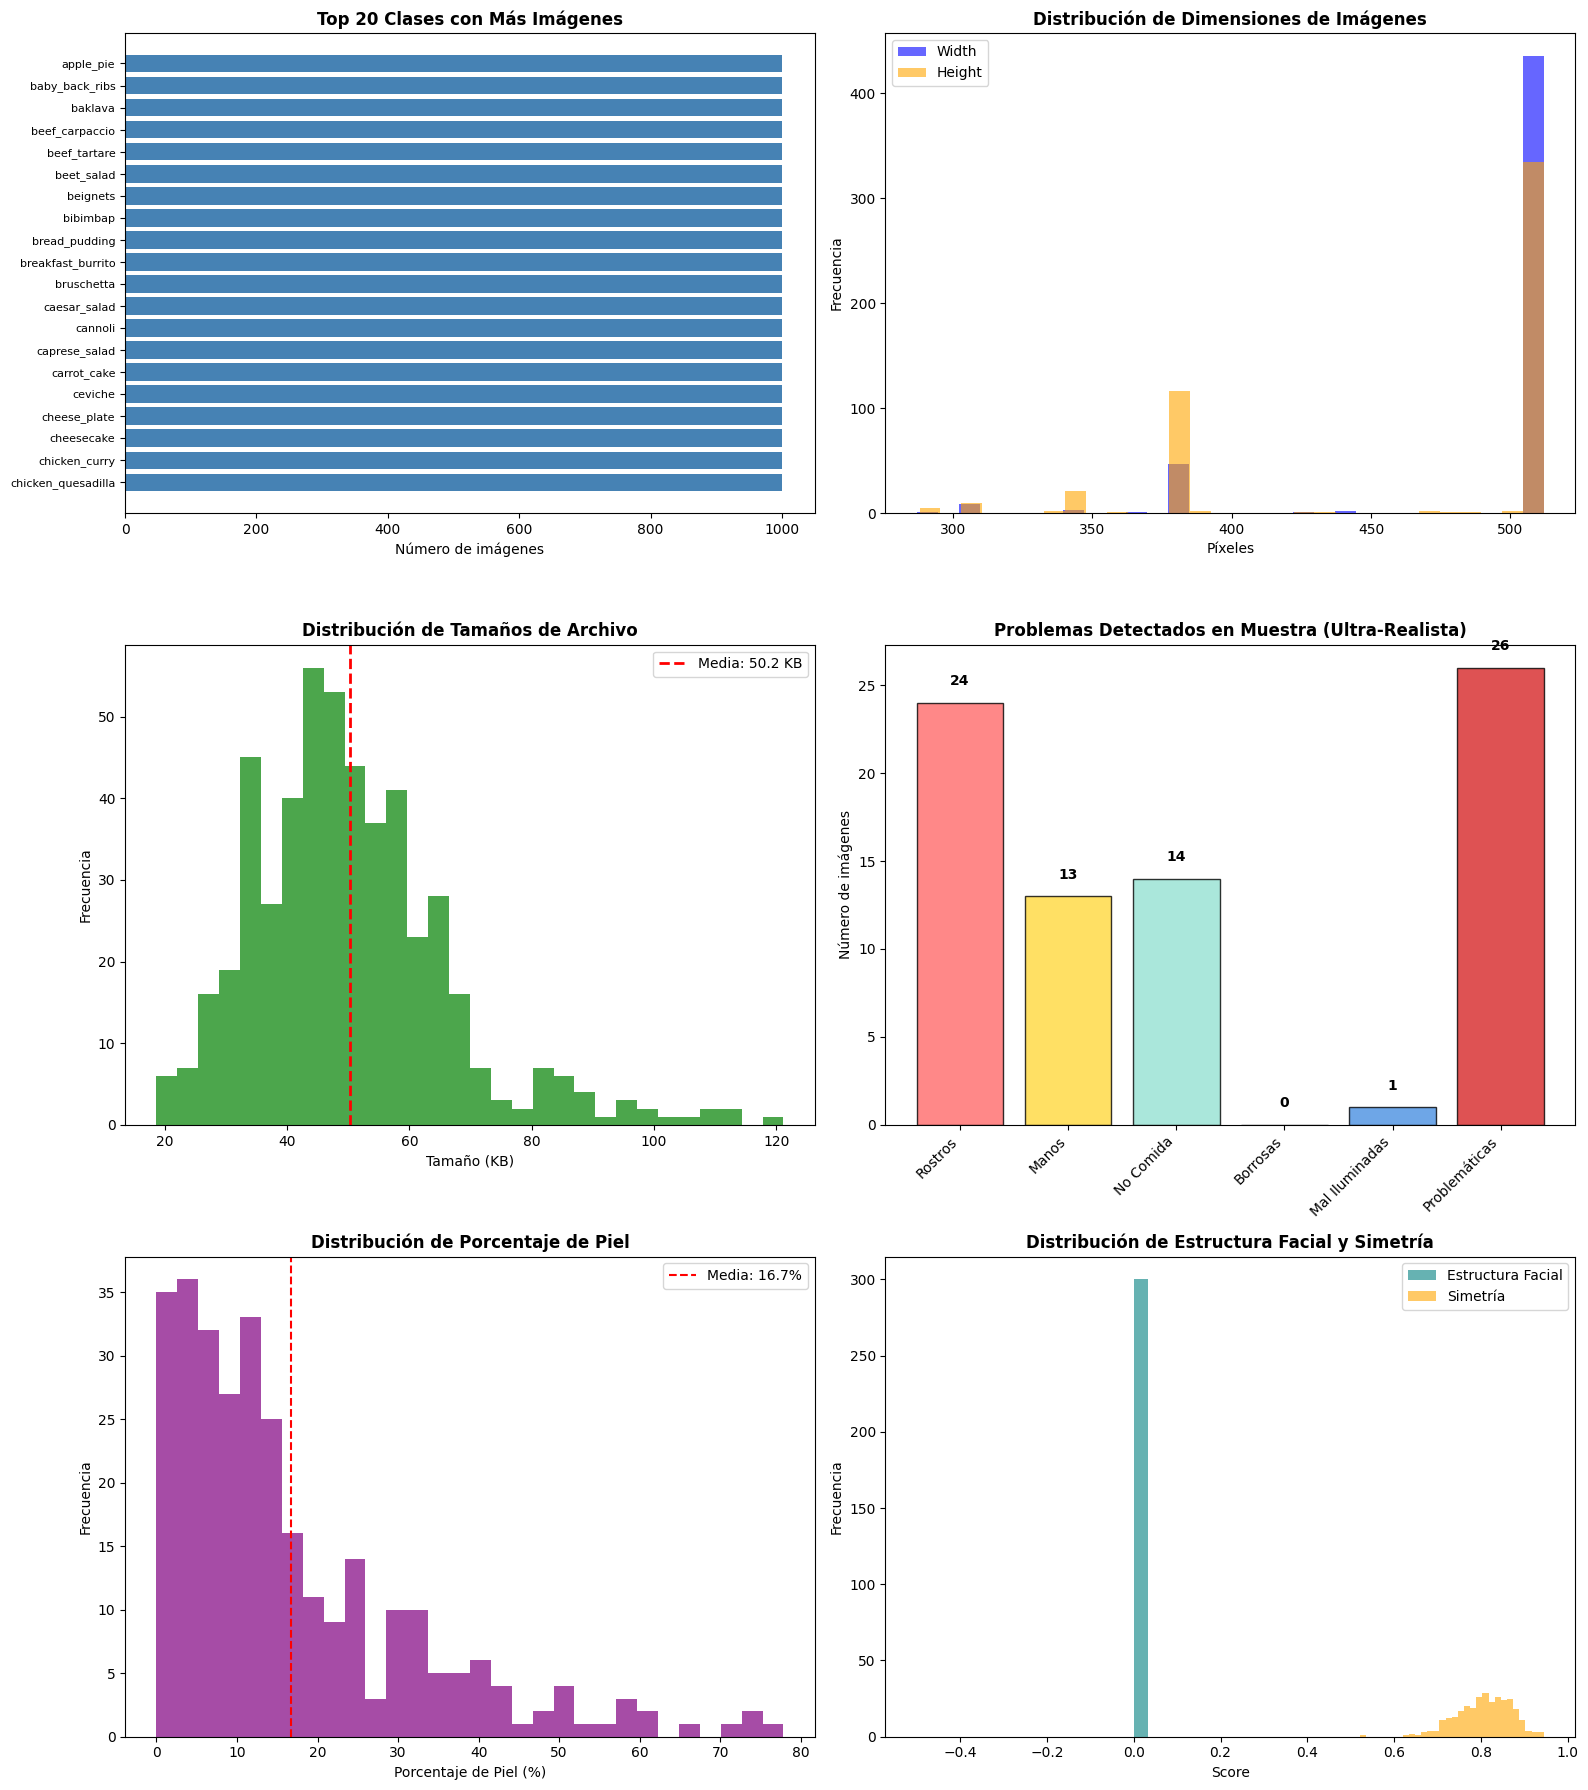

In [34]:
# ============================================================================
# PARTE 6: VISUALIZACIONES (ADAPTADA A ANÁLISIS ULTRA-REALISTA)
# ============================================================================

print("\n[PASO 6] Generando visualizaciones...")
print("-" * 80)

# Asegurar que los gráficos se muestren en el notebook
# pylint: disable=invalid-name
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Limpiar datos no finitos en df_quality
df_quality_clean = df_quality.copy()
for col in ['porcentaje_piel', 'face_structure_score', 'symmetry_score']:
    df_quality_clean[col] = df_quality_clean[col].replace([np.inf, -np.inf], np.nan).fillna(0.0)

# Crear figura con 3 filas: 2x2 para las primeras 4 visualizaciones, 1x2 para métricas continuas
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# 1. Distribución de imágenes por clase (Top 20)
ax1 = axes[0, 0]
top_20 = df_classes.nlargest(20, 'num_imagenes')
ax1.barh(range(len(top_20)), top_20['num_imagenes'].values, color='steelblue')
ax1.set_yticks(range(len(top_20)))
ax1.set_yticklabels(top_20['clase'].values)
ax1.set_xlabel('Número de imágenes')
ax1.set_title('Top 20 Clases con Más Imágenes', fontsize=12, fontweight='bold')
ax1.invert_yaxis()
plt.setp(ax1.get_yticklabels(), fontsize=8)

# 2. Distribución de dimensiones
ax2 = axes[0, 1]
ax2.hist(df_img_features['width'], bins=30, alpha=0.6, label='Width', color='blue')
ax2.hist(df_img_features['height'], bins=30, alpha=0.6, label='Height', color='orange')
ax2.set_xlabel('Píxeles')
ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribución de Dimensiones de Imágenes', fontsize=12, fontweight='bold')
ax2.legend()

# 3. Distribución de tamaños de archivo
ax3 = axes[1, 0]
ax3.hist(df_img_features['file_size_kb'], bins=30, color='green', alpha=0.7)
ax3.set_xlabel('Tamaño (KB)')
ax3.set_ylabel('Frecuencia')
ax3.set_title('Distribución de Tamaños de Archivo', fontsize=12, fontweight='bold')
ax3.axvline(df_img_features['file_size_kb'].mean(), color='red', 
            linestyle='--', linewidth=2, label=f"Media: {df_img_features['file_size_kb'].mean():.1f} KB")
ax3.legend()

# 4. Problemas detectados (adaptado a métricas ultra-realistas)
ax4 = axes[1, 1]
problems = [
    df_quality_clean['tiene_rostro'].sum(),
    df_quality_clean['tiene_manos_obvias'].sum(),
    (~df_quality_clean['es_comida']).sum(),
    (~df_quality_clean['es_nitida']).sum(),
    (~df_quality_clean['buen_brillo_contraste']).sum(),
    df_quality_clean['es_problematica'].sum()
]
problem_labels = ['Rostros', 'Manos', 'No Comida', 'Borrosas', 'Mal Iluminadas', 'Problemáticas']
colors_problems = ['#ff6b6b', '#ffd93d', '#95e1d3', '#ff9a8b', '#4a90e2', '#d62728']
ax4.bar(problem_labels, problems, color=colors_problems, alpha=0.8, edgecolor='black')
ax4.set_ylabel('Número de imágenes')
ax4.set_title('Problemas Detectados en Muestra (Ultra-Realista)', fontsize=12, fontweight='bold')
for i, v in enumerate(problems):
    ax4.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.setp(ax4.get_xticklabels(), rotation=45, ha='right')

# 5. Distribución de porcentaje de piel
ax5 = axes[2, 0]
ax5.hist(df_quality_clean['porcentaje_piel'], bins=30, color='purple', alpha=0.7)
ax5.set_xlabel('Porcentaje de Piel (%)')
ax5.set_ylabel('Frecuencia')
ax5.set_title('Distribución de Porcentaje de Piel', fontsize=12, fontweight='bold')
ax5.axvline(df_quality_clean['porcentaje_piel'].mean(), color='red', linestyle='--', 
            label=f"Media: {df_quality_clean['porcentaje_piel'].mean():.1f}%")
ax5.legend()

# 6. Distribución de estructura facial y simetría
ax6 = axes[2, 1]
ax6.hist(df_quality_clean['face_structure_score'], bins=30, alpha=0.6, label='Estructura Facial', color='teal')
ax6.hist(df_quality_clean['symmetry_score'], bins=30, alpha=0.6, label='Simetría', color='orange')
ax6.set_xlabel('Score')
ax6.set_ylabel('Frecuencia')
ax6.set_title('Distribución de Estructura Facial y Simetría', fontsize=12, fontweight='bold')
ax6.legend()

plt.tight_layout()
plt.show()



In [ ]:
# ============================================================================
# PARTE 7: PREPROCESAMIENTO DE DATOS
# ============================================================================

print("\n[PASO 7] Preprocesamiento de datos...")
print("-" * 80)

TARGET_SIZE = 224  # Tamaño estándar para modelos de transfer learning
VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png'}

def preprocess_dataset(images_path, target_size=224, max_images_per_class=None):
    """
    Preprocesa dataset: carga, redimensiona, normaliza imágenes
    """
    X = []
    y = []
    class_mapping = {}
    problematic_images = []
    
    classes = sorted([d for d in os.listdir(images_path) 
                      if os.path.isdir(os.path.join(images_path, d))])
    
    print(f"\n📥 Cargando y preprocesando {len(classes)} clases...")
    
    for class_idx, class_name in enumerate(classes):
        class_path = os.path.join(images_path, class_name)
        class_mapping[class_idx] = class_name
        
        images = [f for f in os.listdir(class_path) 
                  if os.path.splitext(f)[1].lower() in VALID_EXTENSIONS]
        
        # Limitar imágenes por clase si se especifica
        if max_images_per_class:
            images = images[:max_images_per_class]
        
        for img_name in tqdm(images, desc=f"  {class_name}", leave=False):
            img_path = os.path.join(class_path, img_name)
            try:
                # Cargar imagen
                img = Image.open(img_path).convert('RGB')
                
                # Redimensionar
                img = img.resize((target_size, target_size), Image.Resampling.LANCZOS)
                
                # Convertir a array numpy
                img_array = np.array(img, dtype=np.float32) / 255.0  # Normalizar a [0, 1]
                
                X.append(img_array)
                y.append(class_idx)
            
            except Exception as e:
                problematic_images.append({
                    'image': img_path,
                    'error': str(e)
                })
    
    return np.array(X), np.array(y), class_mapping, problematic_images

# Opción 1: Cargar TODAS las imágenes (toma tiempo)
print("⏳ Cargando dataset completo (esto puede tardar varios minutos)...")
X, y, class_mapping, problematic = preprocess_dataset(images_path, target_size=TARGET_SIZE)

# Opción 2: Cargar muestra (más rápido para desarrollo)
# X, y, class_mapping, problematic = preprocess_dataset(
#     images_path, target_size=TARGET_SIZE, max_images_per_class=50
# )

print(f"\n✅ Dataset preprocesado:")
print(f"   X shape: {X.shape}")
print(f"   y shape: {y.shape}")
print(f"   Imágenes problemáticas: {len(problematic)}")

if problematic:
    print(f"\n⚠️  Primeras 5 errores:")
    for prob in problematic[:5]:
        print(f"   {prob['image']}: {prob['error']}")

# Verificar distribución de clases
unique, counts = np.unique(y, return_counts=True)
print(f"\n🏷️  Distribución de clases:")
for cls_idx, count in zip(unique[:5], counts[:5]):
    print(f"   {class_mapping[cls_idx]}: {count} imágenes")
print(f"   ... ({len(unique)} clases en total)")


[PASO 7] Preprocesamiento de datos...
--------------------------------------------------------------------------------
⏳ Cargando dataset completo (esto puede tardar varios minutos)...

📥 Cargando y preprocesando 101 clases...


KeyboardInterrupt: 

In [ ]:
# ============================================================================
# PARTE 8: ESTADÍSTICAS FINALES
# ============================================================================

print("\n[PASO 8] Estadísticas finales...")
print("-" * 80)

final_stats = {
    'total_clases': len(class_mapping),
    'total_imagenes': len(X),
    'imagen_shape': X.shape,
    'imagen_dtype': str(X.dtype),
    'rango_valores': f"[{X.min():.3f}, {X.max():.3f}]",
    'distribucion_clases': dict(zip(unique, counts)),
    'clase_min_imagenes': counts.min(),
    'clase_max_imagenes': counts.max(),
    'clase_media_imagenes': counts.mean(),
    'imágenes_problemáticas': len(problematic),
    'target_size': TARGET_SIZE
}

print("\n📊 Resumen final:")
for key, value in final_stats.items():
    if key != 'distribucion_clases':
        print(f"   {key}: {value}")

print(f"\n   distribucion_clases: {len(final_stats['distribucion_clases'])} clases")

In [ ]:
# ============================================================================
# PARTE 9: GUARDAR DATASET PREPROCESADO (PKL)
# ============================================================================

print("\n[PASO 9] Guardando dataset preprocesado...")
print("-" * 80)

dataset_package = {
    'X': X,
    'y': y,
    'class_mapping': class_mapping,
    'class_names': list(class_mapping.values()),
    'target_size': TARGET_SIZE,
    'stats': final_stats,
    'problematic_images': problematic,
    'image_features': df_img_features.to_dict('records'),
    'quality_analysis': df_quality.to_dict('records') if len(df_quality) > 0 else []
}

with open(PKL_OUTPUT, 'wb') as f:
    pickle.dump(dataset_package, f)

print(f"✅ Dataset guardado en: {PKL_OUTPUT}")
print(f"   Tamaño del archivo: {os.path.getsize(PKL_OUTPUT) / (1024**3):.2f} GB")

# Guardar también un resumen CSV
summary_df = pd.DataFrame({
    'clase_id': unique,
    'clase_nombre': [class_mapping[i] for i in unique],
    'num_imagenes': counts
})
summary_df.to_csv(os.path.join(OUTPUT_DIR, 'dataset_summary.csv'), index=False)
print(f"✅ Resumen guardado en: dataset_summary.csv")

In [ ]:
# ============================================================================
# PARTE 10: INSTRUCCIONES PARA CARGAR EL DATASET
# ============================================================================

print("\n[PASO 10] Instrucciones para usar el dataset...")
print("-" * 80)

load_code = """
# Para cargar el dataset preprocesado en otro notebook:

import pickle
import numpy as np

with open('./output/food101_preprocessed.pkl', 'rb') as f:
    data = pickle.load(f)

X = data['X']  # Array de imágenes (N, 224, 224, 3) normalizado [0, 1]
y = data['y']  # Array de labels (N,)
class_mapping = data['class_mapping']  # Dict {id: nombre}
class_names = data['class_names']  # List de nombres
stats = data['stats']  # Estadísticas

print(f"Imágenes: {X.shape}")
print(f"Labels: {y.shape}")
print(f"Clases: {len(class_mapping)}")
"""

print(load_code)

# Guardar código de ejemplo
with open(os.path.join(OUTPUT_DIR, 'load_dataset_example.py'), 'w') as f:
    f.write(load_code)

In [ ]:
# ============================================================================
# PARTE 11: RESUMEN FINAL
# ============================================================================

print("\n" + "=" * 80)
print("✅ EDA COMPLETADO EXITOSAMENTE")
print("=" * 80)

print(f"\n📦 Archivos generados en {OUTPUT_DIR}:")
print(f"   ✅ food101_preprocessed.pkl - Dataset preprocesado")
print(f"   ✅ dataset_summary.csv - Resumen por clase")
print(f"   ✅ 01_exploracion_general.png - Gráficos principales")
print(f"   ✅ 02_modos_color.png - Distribución modos color")
print(f"   ✅ load_dataset_example.py - Código para cargar")

print(f"\n📊 Dataset Stats:")
print(f"   • Total de imágenes: {X.shape[0]:,}")
print(f"   • Total de clases: {len(class_mapping)}")
print(f"   • Dimensión imágenes: {TARGET_SIZE}x{TARGET_SIZE}x3")
print(f"   • Rango valores: {X.min():.3f} - {X.max():.3f}")
print(f"   • Imágenes por clase: {counts.min()} - {counts.max()} ({counts.mean():.0f} media)")
print(f"   • Imágenes problemáticas detectadas: {len(problematic)}")

print("\n🚀 Próximos pasos:")
print("   1. Usar el archivo .pkl en el modelo de entrenamiento")
print("   2. Split train/val/test del dataset")
print("   3. Entrenar modelos ensemble (ResNet, DenseNet, EfficientNet)")
print("   4. Evaluar métricas multiclase")

print("\n" + "=" * 80 + "\n")